In [1]:
import numpy               as np
#import seaborn             as sns
import pandas              as pd
import libraries.plotting  as slp
import libraries.utilities as sul
import os

#sns.set_theme()

/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


We only consider coherent interfaces (which has matching lattices from both sides of the interface, meaning that there is a repeat along the interface that lets build periodicity along the interface surface).

In [2]:
# Define name to reference folder which stores the energies of each slab
slab_folder = 'input/test/slab_v0'

The surface formation energy ($E_{surface}$) can be expressed in terms of the area ($S$) of the surface, the energy ($E_{slab}$) of the slab and the energy of the bulk system ($E_{bulk}$) as:

\begin{equation}
    E_{surface} = \frac{E_{slab} - E_{bulk}}{2 S}
\end{equation}

where all energies are per atom.

In [3]:
bulk_folder = f'{slab_folder}/bulk'

# Load the bulk energy
bulk_energy = sul.read_energy(bulk_folder)

# Load bulk information
slab_data = sul.load_json(filename=f'{bulk_folder}/slab_data.json')

n_bulk = slab_data['number_of_sites']

Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [4]:
# Initialize the data dictionary for storing all slab energy calculations
# Iterate over slabs
surface_energies_of_formation = {}
for i, miller_index_str in enumerate(os.listdir(slab_folder)):
    # Define current folder
    miller_folder = f'{slab_folder}/{miller_index_str}'
    print(miller_folder)
    # Skip in case it is not a folder or it is the bulk folder
    if (not os.path.isdir(miller_folder)) or (miller_index_str == 'bulk'):
        continue

    # Load slab information
    slab_data = sul.load_json(filename=f'{miller_folder}/slab_data.json')

    print()
    print(f'Slab {i+1}')
    print()
    print(f'Miller index: {slab_data['miller_index']}')
    print(f'Shift: {slab_data['shift']:.3g}')
    print(f'Surface area: {slab_data['surface_area']:.3g}')
    print(f'Number of sites: {slab_data['number_of_sites']}')

    # Load the single-shot energy
    slab_energy = sul.read_energy(miller_folder)

    print(f'E_total = {slab_energy:.3g} eV')

    bulk_energy_times_fu = bulk_energy * slab_data['number_of_sites'] / n_bulk
    
    # Compute surface energy of formation in eV/atom/ang^2
    surface_energy_of_formation = sul.get_surface_energy_of_formation(slab_energy, bulk_energy_times_fu, slab_data['surface_area'])

    # Save the slab energy
    np.savetxt(f'{miller_folder}/surface_energy_of_formation', [surface_energy_of_formation])

    print(f'\t$E_surface$ = {surface_energy_of_formation:.3g} J/m²')

    # Generate a dictionary object with the new data and update in the main data object
    surface_energies_of_formation.update({
        miller_index_str: surface_energy_of_formation
    })

# Convert to Pandas DataFrame
surface_energies_of_formation = pd.DataFrame(surface_energies_of_formation, index=['energy'])

input/test/slab_v0/0_1_0_i_2

Slab 1

Miller index: [0, 1, 0]
Shift: 0.151
Surface area: 41.5
Number of sites: 36
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


      Step     Time          Energy          fmax
BFGS:    0 10:58:28     -122.464568        0.700004
BFGS:    1 10:58:28     -122.518307        0.650394
BFGS:    2 10:58:28     -122.752591        0.723899
BFGS:    3 10:58:29     -122.776136        0.478007
BFGS:    4 10:58:29     -122.852656        0.331660
BFGS:    5 10:58:29     -122.937467        0.537383
BFGS:    6 10:58:29     -122.990238        0.684268
BFGS:    7 10:58:29     -123.052568        0.667816
BFGS:    8 10:58:29     -123.128576        0.388685
BFGS:    9 10:58:29     -123.190267        0.463562
BFGS:   10 10:58:29     -123.256393        0.747428
BFGS:   11 10:58:30     -123.314600        0.665172
BFGS:   12 10:58:30     -123.348430        0.483534
BFGS:   13 10:58:30     -123.404930        0.419961
BFGS:   14 10:58:30     -123.463318        0.447570
BFGS:   15 10:58:30     -123.505952        0.575698
BFGS:   16 10:58:30     -123.537359        0.530061
BFGS:   17 10:58:30     -123.570859        0.517415
BFGS:   18 10:

/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=F

      Step     Time          Energy          fmax
BFGS:    0 10:58:37     -247.958182        1.539831
BFGS:    1 10:58:37     -248.260081        1.372121
BFGS:    2 10:58:37     -249.469076        2.311822
BFGS:    3 10:58:37     -249.641036        1.199635
BFGS:    4 10:58:38     -249.908573        0.722664
BFGS:    5 10:58:38     -250.241307        0.838576
BFGS:    6 10:58:38     -250.349562        0.985966
BFGS:    7 10:58:38     -250.503909        1.068452
BFGS:    8 10:58:39     -250.697499        0.812157
BFGS:    9 10:58:39     -250.843992        0.448538
BFGS:   10 10:58:39     -250.909118        0.748588
BFGS:   11 10:58:39     -250.972297        0.778505
BFGS:   12 10:58:40     -251.079891        0.494223
BFGS:   13 10:58:40     -251.166866        0.428730
BFGS:   14 10:58:40     -251.240783        0.420336
BFGS:   15 10:58:40     -251.298088        0.529016
BFGS:   16 10:58:41     -251.375992        0.608701
BFGS:   17 10:58:41     -251.481203        0.521442
BFGS:   18 10:

...

E_total = -82.3 eV
	$E_surface$ = 0.594 J/m²
input/test/slab_v0/1_0_0_i_0

Slab 29

Miller index: [1, 0, 0]
Shift: 0
Surface area: 83.6
Number of sites: 60
Using float64 for MACECalculator, which is slower but more accurate. Recommended for geometry optimization.


/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


      Step     Time          Energy          fmax
BFGS:    0 11:04:53     -208.032404        1.626212
BFGS:    1 11:04:53     -208.341470        1.413543
BFGS:    2 11:04:54     -209.191671        1.105492
BFGS:    3 11:04:54     -209.321360        0.623130
BFGS:    4 11:04:54     -209.433981        0.483406
BFGS:    5 11:04:54     -209.754723        0.435067
BFGS:    6 11:04:54     -209.824778        0.485398
BFGS:    7 11:04:55     -209.890922        0.427216
BFGS:    8 11:04:55     -209.974700        0.353405
BFGS:    9 11:04:55     -210.071868        0.481603
BFGS:   10 11:04:55     -210.159213        0.523992
BFGS:   11 11:04:55     -210.224999        0.436313
BFGS:   12 11:04:56     -210.278300        0.421580
BFGS:   13 11:04:56     -210.343635        0.439293
BFGS:   14 11:04:56     -210.411243        0.350606
BFGS:   15 11:04:56     -210.459102        0.300499
BFGS:   16 11:04:56     -210.496477        0.305488
BFGS:   17 11:04:57     -210.546144        0.338162
BFGS:   18 11:

/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/mace/calculators/mace.py:226: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/Users/cibran/work/UPC/SurfAIcing/.venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


E_total = -211 eV
	$E_surface$ = 0.11 J/m²


# Extract local minimas and generate input files

In [5]:
min_arg      = np.argsort(surface_energies_of_formation.values)[0]
local_minima = surface_energies_of_formation.columns[min_arg]
energies     = surface_energies_of_formation.values[0][min_arg]
#local_minima, energies

In [6]:
min_arg_sort = surface_energies_of_formation.T.sort_values(by='energy', ascending=True)
min_arg_sort.to_excel(f'{slab_folder}/sorted_data.xlsx')

In [7]:
import seaborn as sns
sns.set_style("whitegrid")

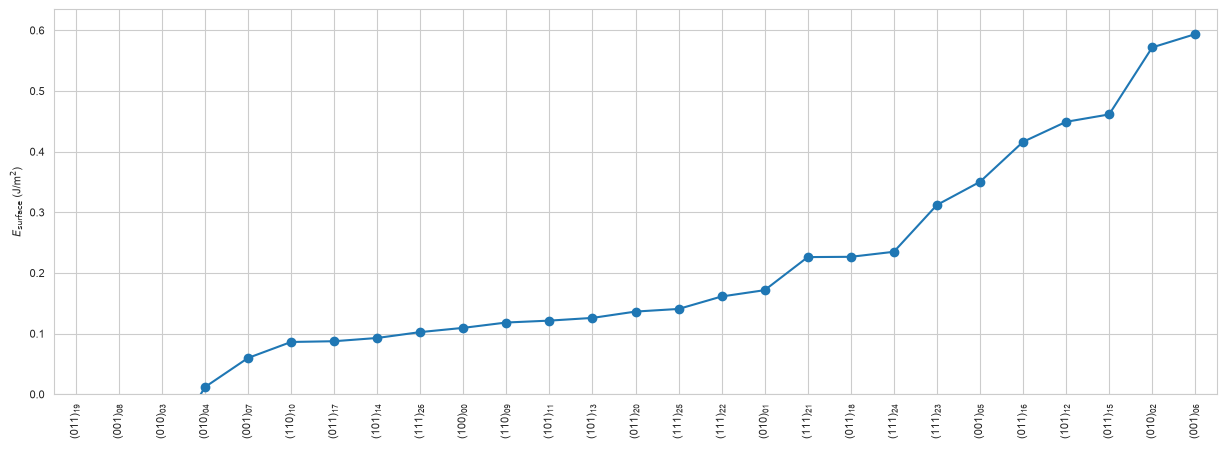

In [8]:
slp.plot_ranking(surface_energies_of_formation,
                 ylabel=r'$E_{\text{surface}}$ (J/m$^2$)',
                 filename=f'{slab_folder}/ranking.png', dpi=300)